# Import libraries

In [1]:

from src.preprocessing.dataLoader_CelebA import get_partitioned_dataloaders
from src.preprocessing.dataLoader_vi import SiameseNetworkDataset
from src.ml.own_network import SiameseNetworkOwn
from src.ml.resNet18 import SiameseNetwork
from src.ml.loss_utils import ContrastiveLoss, ArcFaceLoss
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import torch
import torchvision
import torch.nn.functional as F
import yaml

# 1. Load the data

In [2]:
# Load config from YAML
with open("config/config.yml", "r") as f:
    config = yaml.safe_load(f)

# Extract sections
PRE = config["PREPROCESSING"]
TRAIN = config["TRAINING_CONTRASTIVE"]

# Set constants from preprocessing config
IMAGE_DIR = PRE["image_dir"]
LABEL_FILE = PRE["label_file"]
PARTITION_FILE = PRE["partition_file"]
BATCH_SIZE = 32

M_PER_SAMPLE = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set constants from training config
LR = TRAIN["lr"]
SCHEDULING = TRAIN["scheduling"]
WEIGHT_DECAY = TRAIN["weight_decay"]
NUM_EPOCHS = 1000
PATIENCE = 100
LOSS_TYPE = "contrastive"
DATASET_NAME = "celebA"# "celebA" # ATT
NUM_IDENTITY = 200

In [3]:
def plot_all(train_loader):
    # Assuming train_loader uses FilteredCelebADataset with remapped labels

    # Access the underlying dataset from train_loader
    train_dataset = train_loader.dataset

    # Collect one example image per unique label
    unique_labels = sorted(set(train_dataset.labels))
    label_to_img = {}

    for idx, label in enumerate(train_dataset.labels):
        if label not in label_to_img:
            label_to_img[label] = train_dataset[idx][0]  # Assuming dataset[idx] returns (image, label)

    # Plot all unique labels with their example images
    num_labels = len(unique_labels)
    cols = 10
    rows = (num_labels + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
    axes = axes.flatten()

    for i, label in enumerate(unique_labels):
        img = label_to_img[label].permute(1, 2, 0).numpy()

        # Denormalize (if your dataset applies normalization)
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]
        img = img * std + mean
        img = img.clip(0, 1)

        axes[i].imshow(img)
        axes[i].set_title(f"Label: {label}")
        axes[i].axis('off')

    # Hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


In [4]:
if DATASET_NAME == "celebA":
    # Load datasets
    train_loader, val_loader, test_loader = get_partitioned_dataloaders(
        image_dir=IMAGE_DIR,
        label_file=LABEL_FILE,
        partition_file=PARTITION_FILE,
        m_per_sample=M_PER_SAMPLE,
        batch_size=BATCH_SIZE,
        num_identities=NUM_IDENTITY,
        seed=42
    )
    # plot_all(train_loader=train_loader)
else:
    # Load the training dataset
    folder_dataset = datasets.ImageFolder(root="data/v2/data/faces/training/")

    # Resize the images and transform to tensors
    transformation = transforms.Compose([transforms.Resize((100,100)),
                                        transforms.ToTensor()
                                        ])

    # Initialize the network
    siamese_dataset = SiameseNetworkDataset(imageFolderDataset=folder_dataset,
                                            transform=transformation)
    train_loader = DataLoader(siamese_dataset, shuffle=True, num_workers=0, batch_size=BATCH_SIZE)

    # Locate the test dataset and load it into the SiameseNetworkDataset
    folder_dataset_test = datasets.ImageFolder(root="data/v2/data/faces/validation/")
    siamese_dataset = SiameseNetworkDataset(imageFolderDataset=folder_dataset_test,
                                            transform=transformation)
    val_loader = DataLoader(siamese_dataset, num_workers=0, batch_size=BATCH_SIZE, shuffle=True)

    # Locate the test dataset and load it into the SiameseNetworkDataset
    folder_dataset_test = datasets.ImageFolder(root="data/v2/data/faces/testing/")
    siamese_dataset = SiameseNetworkDataset(imageFolderDataset=folder_dataset_test,
                                            transform=transformation)
    test_loader = DataLoader(siamese_dataset, num_workers=0, batch_size=1, shuffle=True)

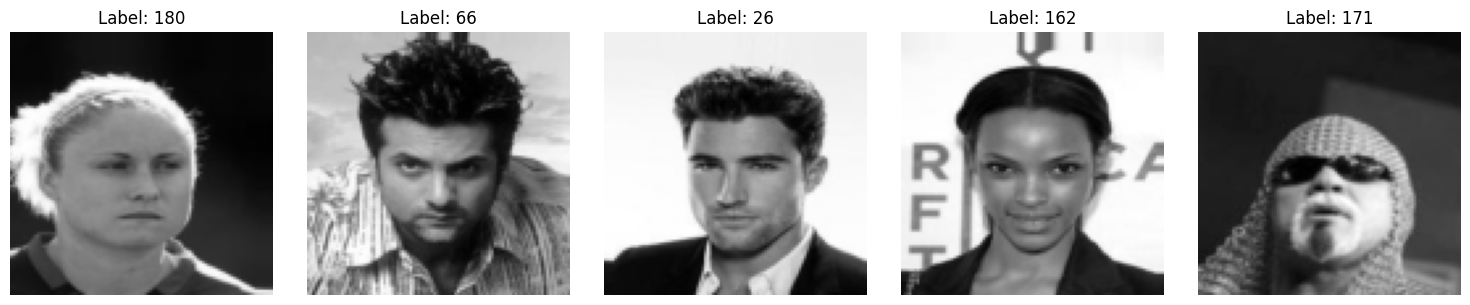

In [5]:
import matplotlib.pyplot as plt
import torch

plt.figure(figsize=(15, 3))

for i in range(5):
    sample = test_loader.dataset[i]
    image, label = sample[0], sample[3]  # image is first, label is fifth

    # Convert image to numpy
    if isinstance(image, torch.Tensor):
        if image.ndim == 3 and image.shape[0] == 1:  # grayscale
            image = image.squeeze().numpy()
            cmap = 'gray'
        elif image.ndim == 3 and image.shape[0] == 3:  # RGB
            image = image.permute(1, 2, 0).numpy()
            cmap = None
        else:
            raise ValueError(f"Unexpected image shape: {image.shape}")
    else:
        cmap = 'gray'

    # Convert label to int
    if isinstance(label, torch.Tensor):
        label = label.item()

    plt.subplot(1, 5, i + 1)
    plt.imshow(image, cmap=cmap)
    plt.title(f"Label: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [6]:
num_batches_val = len(val_loader)
print(f"Number of batches in validation dataloader: {num_batches_val}")
num_samples_train = len(train_loader.dataset)
num_batches_train = len(train_loader)
print(f"Training samples: {num_samples_train}, Batches: {num_batches_train}")

Number of batches in validation dataloader: 19
Training samples: 2803, Batches: 87


# Create the model

In [7]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = SiameseNetwork().to(DEVICE)
#net = SiameseNetworkOwn().to(DEVICE)

# Train Model

In [8]:
loss_type = LOSS_TYPE

if loss_type == "contrastive":
    criterion = ContrastiveLoss(margin=20).to(DEVICE)
elif loss_type == "arcface":
    criterion = ArcFaceLoss(num_classes=NUM_IDENTITY, embedding_size=256).to(DEVICE)
elif loss_type == "multisimilarity":
    import pytorch_metric_learning.losses as losses
    criterion = losses.MultiSimilarityLoss(alpha=2, beta=50, base=0.5).to(DEVICE)


In [9]:
# Showing images
def imshow(img, text=None):
    npimg = img.numpy()
    plt.axis("off")
    if text:
        plt.text(75, 8, text, style='italic',fontweight='bold',
            bbox={'facecolor':'white', 'alpha':0.8, 'pad':10})
        
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()    

# Plotting data
def show_plot(iteration,loss):
    plt.plot(iteration,loss)
    plt.show()

In [10]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.optim import lr_scheduler

# Initialize lists to store losses
batch_loss_history = []
batch_val_loss_history = []
epoch_loss_history = []
epoch_val_loss_history = []

learning_rate = 0.0005
scheduler_type = "ReduceLROnPlateau"  # <-- Change this to try others

# Assume net, train_loader, val_loader are defined
optimizer = optim.Adam(net.parameters(), lr=0.0005, weight_decay=1e-4)


# Scheduler setup
if scheduler_type == "StepLR":
    scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
elif scheduler_type == "ExponentialLR":
    scheduler = lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
elif scheduler_type == "ReduceLROnPlateau":
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=10)
elif scheduler_type == "CosineAnnealingLR":
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
elif scheduler_type == "OneCycleLR":
    scheduler = lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.01,
        steps_per_epoch=len(train_loader), epochs=NUM_EPOCHS
    )
else:
    raise ValueError(f"Unsupported scheduler: {scheduler_type}")



for epoch in range(NUM_EPOCHS):
    net.train()
    cum_loss = 0
    pbar = tqdm(enumerate(train_loader, 0), total=len(train_loader),
                desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Training]", leave=True)

    for i, (img0, img1, label, label0, label1) in pbar:
        img0, img1, label = img0.to(DEVICE), img1.to(DEVICE), label.to(DEVICE)
        label0, label1 = label0.to(DEVICE), label1.to(DEVICE)

        optimizer.zero_grad()
        output1, output2 = net(img0, img1)

        if loss_type == "contrastive":
            loss = criterion(output1, output2, label)
        elif loss_type == "multisimilarity":
            embeddings = torch.cat([output1, output2])
            labels = torch.cat([label0, label1])
            loss = criterion(embeddings, labels)
        elif loss_type == "arcface":
            loss = criterion(output1, output2, label0, label1)

        loss.backward()
        optimizer.step()

        cum_loss += loss.item()
        batch_loss_history.append(loss.item())  # Add batch loss to history
        if scheduler_type == "OneCycleLR":
                scheduler.step() 

        avg_train_loss = cum_loss / (i + 1)
        
        current_lr = optimizer.param_groups[0]['lr']
        # Update progress bar
        pbar.set_postfix({
            'Train Loss': f"{avg_train_loss:.4f}",
            'Val Loss': f"{epoch_val_loss_history[-1]:.4f}" if epoch_val_loss_history else '--',
            'lr': f"{current_lr:.6f}"
        })

    # End of epoch - store average losses
    epoch_loss_history.append(avg_train_loss)
    
    # Validation phase at end of epoch
    net.eval()
    val_loss = 0.0
    with torch.no_grad():
        for img0, img1, label, label0, label1 in val_loader:
            img0, img1, label = img0.to(DEVICE), img1.to(DEVICE), label.to(DEVICE)
            label0, label1 = label0.to(DEVICE), label1.to(DEVICE)

            output1, output2 = net(img0, img1)

            if loss_type == "contrastive":
                loss = criterion(output1, output2, label)
            elif loss_type == "multisimilarity":
                embeddings = torch.cat([output1, output2])
                labels = torch.cat([label0, label1])
                loss = criterion(embeddings, labels)
            elif loss_type == "arcface":
                loss = criterion(output1, output2, label0, label1)

            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader)
    epoch_val_loss_history.append(avg_val_loss)
    # Scheduler step (if not OneCycleLR)
    if scheduler_type != "OneCycleLR":
        if scheduler_type == "ReduceLROnPlateau":
            scheduler.step(avg_val_loss)
        else:
            scheduler.step()
    
    
    # Update progress bar with final validation loss for this epoch
    pbar.set_postfix({
        'Train Loss': f"{avg_train_loss:.4f}",
        'Val Loss': f"{avg_val_loss:.4f}",
    })
    pbar.close()

# Plotting the losses
plt.figure(figsize=(12, 6))

# Plot batch losses if we tracked them
if batch_loss_history:
    plt.subplot(1, 2, 1)
    plt.plot(batch_loss_history, label='Batch Train Loss')
    if batch_val_loss_history:
        plt.plot(batch_val_loss_history, label='Batch Val Loss')
    plt.title('Batch Loss History')
    plt.xlabel('Batch Number')
    plt.ylabel('Loss')
    plt.legend()

# Plot epoch losses
plt.subplot(1, 2, 2)
plt.plot(epoch_loss_history, label='Epoch Train Loss')
plt.plot(epoch_val_loss_history, label='Epoch Val Loss')
plt.title('Epoch Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Epoch 65/1000 [Training]:  66%|██████▌   | 57/87 [01:00<00:31,  1.06s/it, Train Loss=25.9072, Val Loss=31.9427, lr=0.000500]


KeyboardInterrupt: 

In [44]:
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=2)
optimizer.param_groups[0]['lr'] = 1e-7
PATIENCE = 5
START = 105
END = 200 
for epoch in range(START, END):
    net.train()
    cum_loss = 0
    pbar = tqdm(enumerate(train_loader, 0), total=len(train_loader),
                desc=f"Epoch {epoch + 1}/{END} [Training]", leave=True)

    for i, (img0, img1, label, label0, label1) in pbar:
        img0, img1, label = img0.to(DEVICE), img1.to(DEVICE), label.to(DEVICE)
        label0, label1 = label0.to(DEVICE), label1.to(DEVICE)

        optimizer.zero_grad()
        output1, output2 = net(img0, img1)

        if loss_type == "contrastive":
            loss = criterion(output1, output2, label)
        elif loss_type == "multisimilarity":
            embeddings = torch.cat([output1, output2])
            labels = torch.cat([label0, label1])
            loss = criterion(embeddings, labels)
        elif loss_type == "arcface":
            loss = criterion(output1, output2, label0, label1)

        loss.backward()
        optimizer.step()

        cum_loss += loss.item()
        batch_loss_history.append(loss.item())  # Add batch loss to history
        if scheduler_type == "OneCycleLR":
                scheduler.step() 

        avg_train_loss = cum_loss / (i + 1)
        
        current_lr = optimizer.param_groups[0]['lr']
        # Update progress bar
        pbar.set_postfix({
            'Train Loss': f"{avg_train_loss:.4f}",
            'Val Loss': f"{epoch_val_loss_history[-1]:.4f}" if epoch_val_loss_history else '--',
            'lr': f"{current_lr:.8f}"
        })

    # End of epoch - store average losses
    epoch_loss_history.append(avg_train_loss)
    
    # Validation phase at end of epoch
    net.eval()
    val_loss = 0.0
    with torch.no_grad():
        for img0, img1, label, label0, label1 in val_loader:
            img0, img1, label = img0.to(DEVICE), img1.to(DEVICE), label.to(DEVICE)
            label0, label1 = label0.to(DEVICE), label1.to(DEVICE)

            output1, output2 = net(img0, img1)

            if loss_type == "contrastive":
                loss = criterion(output1, output2, label)
            elif loss_type == "multisimilarity":
                embeddings = torch.cat([output1, output2])
                labels = torch.cat([label0, label1])
                loss = criterion(embeddings, labels)
            elif loss_type == "arcface":
                loss = criterion(output1, output2, label0, label1)

            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader)
    epoch_val_loss_history.append(avg_val_loss)
    # Scheduler step (if not OneCycleLR)
    if scheduler_type != "OneCycleLR":
        if scheduler_type == "ReduceLROnPlateau":
            scheduler.step(avg_val_loss)
        else:
            scheduler.step()
    
    
    # Update progress bar with final validation loss for this epoch
    pbar.set_postfix({
        'Train Loss': f"{avg_train_loss:.4f}",
        'Val Loss': f"{avg_val_loss:.4f}",
    })
    pbar.close()

# Plotting the losses
plt.figure(figsize=(12, 6))

# Plot batch losses if we tracked them
if batch_loss_history:
    plt.subplot(1, 2, 1)
    plt.plot(batch_loss_history, label='Batch Train Loss')
    if batch_val_loss_history:
        plt.plot(batch_val_loss_history, label='Batch Val Loss')
    plt.title('Batch Loss History')
    plt.xlabel('Batch Number')
    plt.ylabel('Loss')
    plt.legend()

# Plot epoch losses
plt.subplot(1, 2, 2)
plt.plot(epoch_loss_history, label='Epoch Train Loss')
plt.plot(epoch_val_loss_history, label='Epoch Val Loss')
plt.title('Epoch Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Epoch 106/200 [Training]:  55%|█████▌    | 48/87 [00:47<00:38,  1.02it/s, Train Loss=11.3514, Val Loss=14.3282, lr=0.00000010]


KeyboardInterrupt: 

In [46]:
import mlflow
import mlflow

# Set or create experiment
mlflow.set_experiment("contrastive_loss_experiment")

with mlflow.start_run():
    # Save checkpoint
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': net.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': epoch_loss_history,
        'val_loss': epoch_val_loss_history,
        'batch_train_loss': batch_loss_history,
        'batch_val_loss': batch_val_loss_history if 'batch_val_loss_history' in locals() else None,
    }, 'models/CONTRASTIVE_RESNET.pth')

    # Log artifact
    mlflow.log_artifact('models/CONTRASTIVE_RESNET.pth')

    # Log final losses
    mlflow.log_metric("final_train_loss", epoch_loss_history[-1])
    mlflow.log_metric("final_val_loss", epoch_val_loss_history[-1])


✅ Average Intra-Class Distance: 2.7508
✅ Average Inter-Class Distance: 38.9481


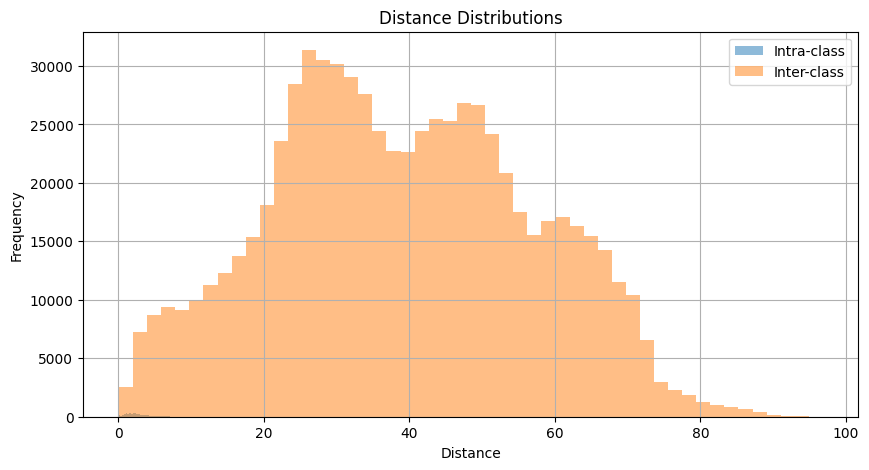

In [21]:
from collections import defaultdict
from itertools import combinations
import torch.nn.functional as F

# Set model to evaluation mode
net.eval()

# Collect embeddings and labels from validation set
all_embeddings = []
all_labels = []

with torch.no_grad():
    for img0, img1, _, label0, label1 in val_loader:
        img0, img1 = img0.to(DEVICE), img1.to(DEVICE)
        label0, label1 = label0.to(DEVICE), label1.to(DEVICE)
        output1, output2 = net(img0, img1)

        all_embeddings.append(torch.cat([output1, output2]))
        all_labels.append(torch.cat([label0, label1]))

# Concatenate all embeddings and labels
all_embeddings = torch.cat(all_embeddings)  # shape: [N, D]
all_labels = torch.cat(all_labels)          # shape: [N]

# Group embeddings by class
class_to_embeddings = defaultdict(list)
for emb, label in zip(all_embeddings, all_labels):
    class_to_embeddings[label.item()].append(emb)

for key in class_to_embeddings:
    class_to_embeddings[key] = torch.stack(class_to_embeddings[key])

# Compute intra-class distances
intra_dists = []
for emb_list in class_to_embeddings.values():
    if len(emb_list) < 2:
        continue  # skip if only one sample
    for i, j in combinations(range(len(emb_list)), 2):
        dist = F.pairwise_distance(emb_list[i].unsqueeze(0), emb_list[j].unsqueeze(0))
        intra_dists.append(dist.item())

# Compute inter-class distances
inter_dists = []
label_keys = list(class_to_embeddings.keys())
for i in range(len(label_keys)):
    for j in range(i+1, len(label_keys)):
        emb_i = class_to_embeddings[label_keys[i]]
        emb_j = class_to_embeddings[label_keys[j]]
        for e1 in emb_i:
            for e2 in emb_j:
                dist = F.pairwise_distance(e1.unsqueeze(0), e2.unsqueeze(0))
                inter_dists.append(dist.item())

# Compute statistics
avg_intra = sum(intra_dists) / len(intra_dists)
avg_inter = sum(inter_dists) / len(inter_dists)

print(f"✅ Average Intra-Class Distance: {avg_intra:.4f}")
print(f"✅ Average Inter-Class Distance: {avg_inter:.4f}")

# Optional: Visualize distributions
plt.figure(figsize=(10, 5))
plt.hist(intra_dists, bins=50, alpha=0.5, label='Intra-class')
plt.hist(inter_dists, bins=50, alpha=0.5, label='Inter-class')
plt.title("Distance Distributions")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


In [22]:
separation_ratio = avg_inter / avg_intra
print(f"🔍 Inter/Intra-Class Distance Ratio: {separation_ratio:.2f}")


🔍 Inter/Intra-Class Distance Ratio: 14.16


Sample counts per selected label:
Label 108: 5 samples
Label 70: 2 samples
Label 14: 13 samples
Running t-SNE with perplexity=6 on 20 samples...


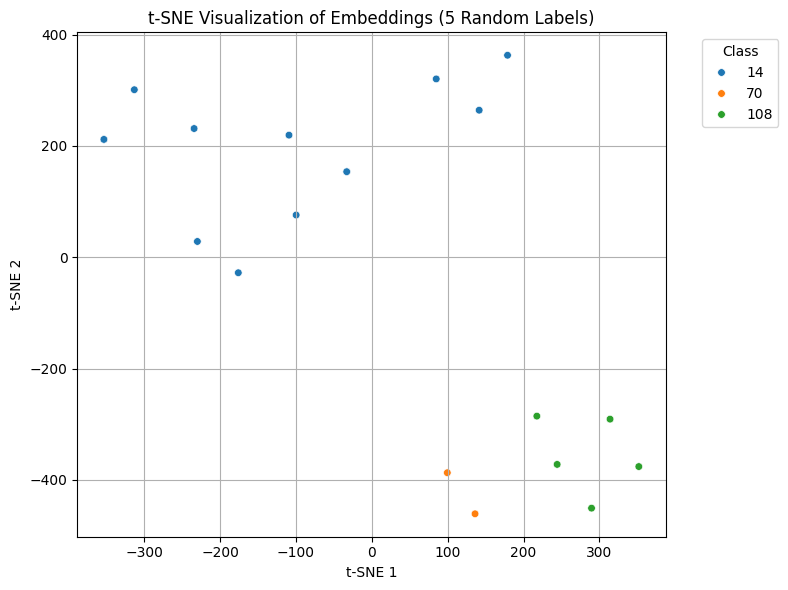

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
num = 3
# Convert tensors to NumPy arrays
X = all_embeddings.cpu().numpy()
y = all_labels.cpu().numpy()

# Randomly select 5 unique labels
unique_labels = np.unique(y)
selected_labels = np.random.choice(unique_labels, size=num, replace=False)

# Filter data
mask = np.isin(y, selected_labels)
X_filtered = X[mask]
y_filtered = y[mask]

# Show counts per selected label before running t-SNE
print("Sample counts per selected label:")
for label in selected_labels:
    count = np.sum(y_filtered == label)
    print(f"Label {label}: {count} samples")

# Dynamically adjust perplexity based on sample count
n_samples = X_filtered.shape[0]
perplexity = min(30, (n_samples - 1) // 3)  # perplexity < n_samples / 3

if perplexity < num:
    raise ValueError(f"Too few samples ({n_samples}) for t-SNE to work reliably with 5 labels.")

# --- t-SNE ---
print(f"Running t-SNE with perplexity={perplexity} on {n_samples} samples...")
tsne = TSNE(n_components=2, perplexity=perplexity, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_filtered)

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_filtered, palette='tab10', legend='full', s=30)
plt.title("t-SNE Visualization of Embeddings (5 Random Labels)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()
